## Setup

In [1]:
# Import packages
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Make plots larger
plt.rcParams["figure.figsize"] = (10, 5)

# Define log directory
# LOG_DIR = Path("/rds/general/user/ll1225/home/imperial_irp/extended_evo1/training_metrics/agvla_habitatsim/stage1")
# LOG_DIR = Path("/rds/general/user/ll1225/home/imperial_irp/extended_evo1/training_metrics/agvla_habitatsim/stage2")
# LOG_DIR = Path("/rds/general/user/ll1225/home/imperial_irp/extended_evo1/training_metrics/agvla_habitatsim")
LOG_DIR = Path("/rds/general/user/ll1225/home/imperial_irp/extended_evo1")

*Run this block if want to use log file of latest run*

In [20]:
# Get log file of latest run
csv_files = sorted(LOG_DIR.glob("training_metrics_*.csv")) # Get and sort all files ending with training_metrics_*.csv
print(f"Found {len(csv_files)} metric logs") # Print found log files
latest_file = csv_files[-1] # Get log file of latest run
print("Using:", latest_file) # Print the log file being used

Found 5 metric logs
Using: /rds/general/user/ll1225/home/imperial_irp/extended_evo1/training_metrics/agvla_habitatsim/stage1/training_metrics_20260714_104109.csv


*Run this block if want to define a specific run to use*

In [2]:
# Define specific log file to use
# FILE_NAME = "training_metrics_20260712_070310.csv" # AGVLA (base Evo1), stage 1 training (10 min test)
# FILE_NAME = "training_metrics_20260713_050542.csv" # AGVLA (base Evo1), stage 1 training
# FILE_NAME = "training_metrics_20260714_102222.csv" # AGVLA (base Evo1), stage 2 training
# FILE_NAME = "training_metrics_20260720_001638.csv" # AGVLA (base Evo1), stage 2 resume 1 training
# FILE_NAME = "training_metrics_20260719_134608.csv" # AGVLA (base Evo1), only hm3d_8 stage 1 training
# FILE_NAME = "training_metrics_20260719_160654.csv" # AGVLA (base Evo1), only hm3d_2 stage 1 training
# FILE_NAME = "training_metrics_20260719_180206.csv" # AGVLA (base Evo1), only hm3d_3 stage 1 training
# FILE_NAME = "training_metrics_20260719_212435.csv" # AGVLA (base Evo1), only hm3d_9 stage 1 training
# FILE_NAME = "training_metrics_20260719_214604.csv" # AGVLA (base Evo1), only hm3d_6 stage 1 training
# FILE_NAME = "training_metrics_20260723_001709.csv" # AGVLA (base Evo1), only hm3d_4 stage 1 training (horizon of 10 only) (on A40)
# FILE_NAME = "training_metrics_20260723_201053.csv" # AGVLA (base Evo1), only hm3d_4 stage 1 training (on A40)
### Trained on dataset with yaw wrapping logic ###
# FILE_NAME = "training_metrics_20260725_215809.csv" # AGVLA (base Evo1), stage 1 training (on A40)
# FILE_NAME = "training_metrics_20260726_072920.csv" # AGVLA (base Evo1), stage 2 training (only to 20000 steps) (on A40)
# FILE_NAME = "training_metrics_20260726_175421.csv" # AGVLA (base Evo1), stage 2 resume training (up to 40000 steps) (on A40)
# FILE_NAME = "training_metrics_20260727_033628.csv" # AGVLA (base Evo1), stage 1 training (with smaller dataset, only hm3d_1-6) (on A40)
# FILE_NAME = "training_metrics_20260727_192315.csv" # AGVLA (base Evo1), stage 2 training (with smaller dataset, only hm3d_1-6) (on A40)
# FILE_NAME = "training_metrics_20260728_005654.csv" # AGVLA (base Evo1), only hm3d_4 stage 1 training, with horizon of 10 (on A40)
# FILE_NAME = "training_metrics_20260728_015808.csv" # AGVLA (base Evo1), stage 2 resume training (with smaller dataset, only hm3d_1-6) (on A40) (up to 36570 steps)
# FILE_NAME = "training_metrics_20260728_105942.csv" # AGVLA (base Evo1), only hm3d_4 stage 2 training, with horizon of 10 (on A40)
# FILE_NAME = "training_metrics_20260728_184054.csv" # AGVLA (base Evo1), stage 2 resume 2 training (with smaller dataset, only hm3d_1-6) (on A40)
# FILE_NAME = "training_metrics_20260729_033041.csv" # AGVLA (base Evo1), stage 1 training, 10 horizon (with smaller dataset, only hm3d_1-6) (on A40)
# FILE_NAME = "training_metrics_20260729_104156.csv" # AGVLA (base Evo1), stage 2 training, 10 horizon (with smaller dataset, only hm3d_1-6) (on A40)
# FILE_NAME = "training_metrics_20260730_150610.csv" # AGVLA (base Evo1), stage 1 training, 10 horizon, trajectory-relative states (with only hm3d_1 scenes) (on A40)
# FILE_NAME = "training_metrics_20260731_023650.csv" # AGVLA (base Evo1), stage 1 training, 10 horizon, masked states, trajectory-relative states (with only hm3d_1 scenes) (on A40)
# FILE_NAME = "training_metrics_20260731_124516.csv" # AGVLA (base Evo1), stage 1 training, 10 horizon, masked states, trajectory-relative states (with only one hm3d_4 traj) (on A40)
# FILE_NAME = "training_metrics_20260731_132151.csv" # AGVLA (base Evo1), stage 1 training, 50 horizon, masked states, trajectory-relative states (with only one hm3d_4 traj) (on A40)
# FILE_NAME = "training_metrics_20260731_151000.csv" # AGVLA (base Evo1), stage 2 training, 10 horizon, masked states, trajectory-relative states (with only one hm3d_4 traj) (on A40)
# FILE_NAME = "training_metrics_20260801_020656.csv" # AGVLA (base Evo1), stage 2 resume training, 10 horizon, masked states, trajectory-relative states (with only one hm3d_4 traj) (on A40)
### Parallel action head WITH DOUBLE REL STATE CONVERSION ISSUE ###
# FILE_NAME = "training_metrics_20260803_201309.csv" # AGVLA (parallel action head), stage 1 training, 10 horizon, trajectory-relative states (only hm3d_1-6 and LIBERO Spatial) (on A40)
# FILE_NAME = "training_metrics_20260804_030659.csv" # AGVLA (parallel action head), stage 2 training, 10 horizon, trajectory-relative states (only hm3d_1-6 and LIBERO Spatial) (on A40)
# FILE_NAME = "training_metrics_20260805_012221.csv" # AGVLA (parallel action head), stage 2 resume training, 10 horizon, trajectory-relative states (only hm3d_1-6 and LIBERO Spatial) (on A40)
# FILE_NAME = "training_metrics_20260805_103452.csv" # AGVLA (parallel action head), stage 1 training, 10 horizon, trajectory-relative states (only hm3d_4) (on A40)
# FILE_NAME = "training_metrics_20260805_140939.csv" # AGVLA (parallel action head), stage 2 training, 10 horizon, trajectory-relative states (only hm3d_4) (on A40)
# FILE_NAME = "training_metrics_20260806_010729.csv" # AGVLA (parallel action head), stage 1 training, 10 horizon, trajectory-relative states (on full hm3d_1-2 and LIBERO Spatial) (on A40)
# FILE_NAME = "training_metrics_20260806_041522.csv" # AGVLA (parallel action head), stage 2 training, 10 horizon, trajectory-relative states (on full hm3d_1-2 and LIBERO Spatial) (on A40)
# FILE_NAME = "training_metrics_20260806_123750.csv" # AGVLA (parallel action head), stage 2 resume training, 10 horizon, trajectory-relative states (on full hm3d_1-2 and LIBERO Spatial) (on A40)
# FILE_NAME = "training_metrics_20260807_022608.csv" # AGVLA (parallel action head), stage 1 long training, 10 horizon, trajectory-relative states (on full hm3d_1-2 and LIBERO Spatial) (on A40)
# FILE_NAME = "training_metrics_20260807_142326.csv" # AGVLA (parallel action head), stage 1 resume long training, 10 horizon, trajectory-relative states (on full hm3d_1-2 and LIBERO Spatial) (on A40)
### Parallel action head ###
FILE_NAME = "training_metrics_20260808_111919.csv" # AGVLA (parallel action head), stage 1 training, 10/50 horizon, trajectory-relative states (on full hm3d_1-2 and LIBERO Spatial) (on A40)
latest_file = LOG_DIR / FILE_NAME
print("Using", latest_file) # Print the log file being used

Using /rds/general/user/ll1225/home/imperial_irp/extended_evo1/training_metrics_20260808_111919.csv


## Plotting

#### Read CSV

In [3]:
# Read CSV file to plot
df = pd.read_csv(latest_file)
df.head() # Show CSV headings

,step,epoch,mse_loss,nav_mse_x,nav_mse_y,nav_mse_z,nav_mse_angle1,nav_mse_angle2,nav_mse_angle3,nav_mse_gripper,...,manip_mse_gripper,mae_loss,nav_samples,manip_samples,batch_size,valid_nav_entries,valid_manip_entries,total_entries,learning_rate,grad_norm
0,0,0.000000,0.515625,1.953125,1.968750,2.296875,0.0,0.0,2.937500,0.0,...,4.40625,0.589844,12,4,16,480.0,1400.0,1880.0,1.000000e-08,0.0
1,10,0.001217,0.550781,1.859375,2.687500,1.859375,0.0,0.0,3.359375,0.0,...,4.59375,0.613281,8,8,16,320.0,2800.0,3120.0,1.100000e-07,0.0
2,20,0.002435,0.527344,2.125000,2.281250,2.265625,0.0,0.0,2.890625,0.0,...,4.71875,0.593750,10,6,16,400.0,2096.0,2496.0,2.100000e-07,0.0
3,30,0.003652,0.515625,2.890625,1.820312,2.093750,0.0,0.0,3.281250,0.0,...,4.25000,0.589844,12,4,16,480.0,1400.0,1880.0,3.100000e-07,0.0
4,40,0.004870,0.593750,1.804688,2.187500,2.484375,0.0,0.0,4.406250,0.0,...,4.90625,0.628906,8,8,16,320.0,2800.0,3120.0,4.100000e-07,0.0


#### Plot MSE loss

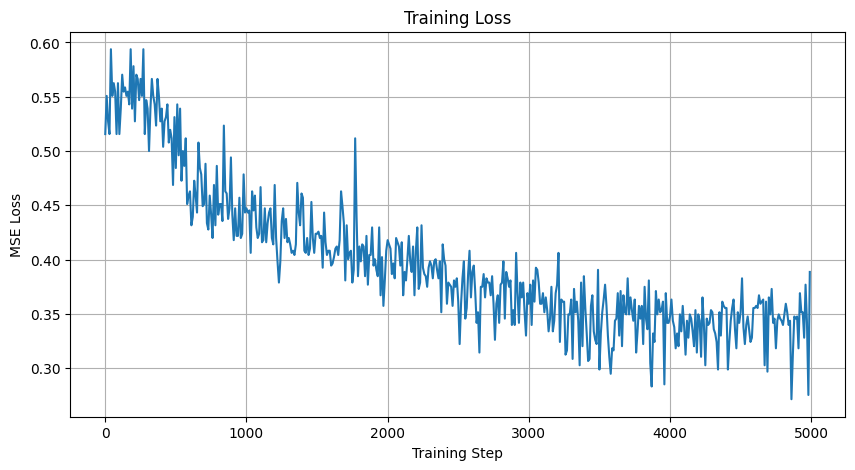

In [4]:
plt.figure()

plt.plot(df["step"], df["mse_loss"])

plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()

#### Plot per dimension loss

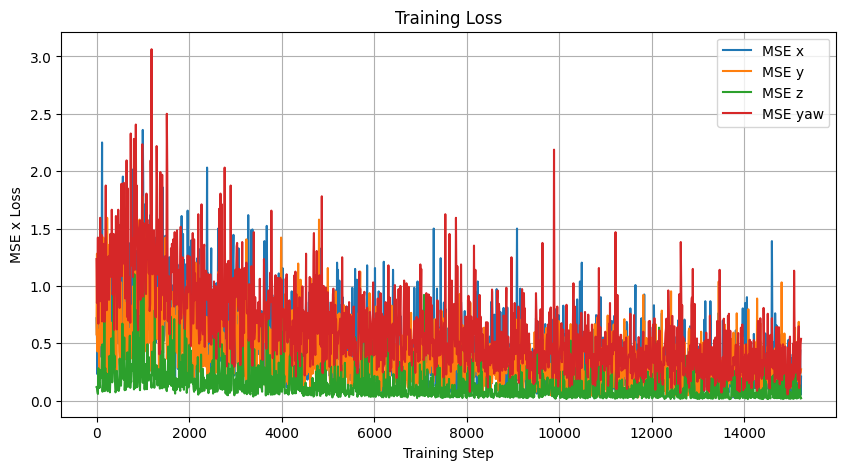

In [6]:
plt.figure()

plt.plot(df["step"], df["mse_x"], label="MSE x")
plt.plot(df["step"], df["mse_y"], label="MSE y")
plt.plot(df["step"], df["mse_z"], label="MSE z")
plt.plot(df["step"], df["mse_angle3"], label="MSE yaw")

plt.xlabel("Training Step")
plt.ylabel("MSE x Loss")
plt.title("Training Loss")

plt.legend()
plt.grid(True)

plt.show()

#### Plot per dimension loss (both navigation and manipulation dims)

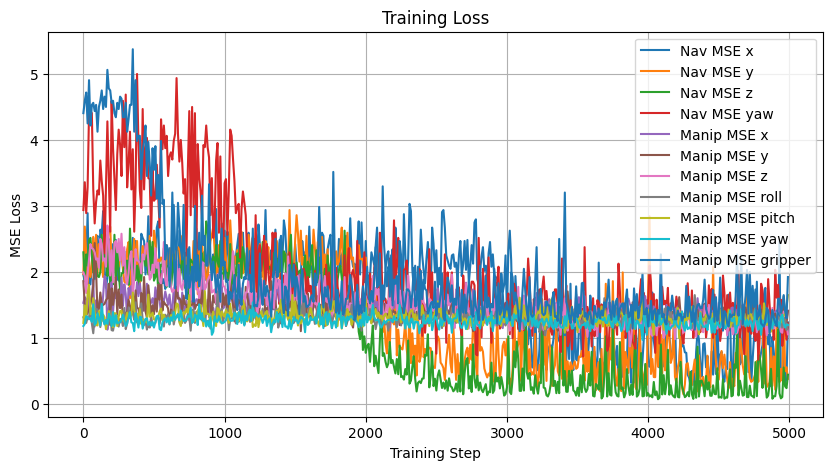

In [8]:
plt.figure()

plt.plot(df["step"], df["nav_mse_x"], label="Nav MSE x")
plt.plot(df["step"], df["nav_mse_y"], label="Nav MSE y")
plt.plot(df["step"], df["nav_mse_z"], label="Nav MSE z")
plt.plot(df["step"], df["nav_mse_angle3"], label="Nav MSE yaw")
plt.plot(df["step"], df["manip_mse_x"], label="Manip MSE x")
plt.plot(df["step"], df["manip_mse_y"], label="Manip MSE y")
plt.plot(df["step"], df["manip_mse_z"], label="Manip MSE z")
plt.plot(df["step"], df["manip_mse_angle1"], label="Manip MSE roll")
plt.plot(df["step"], df["manip_mse_angle2"], label="Manip MSE pitch")
plt.plot(df["step"], df["manip_mse_angle3"], label="Manip MSE yaw")
plt.plot(df["step"], df["manip_mse_gripper"], label="Manip MSE gripper")

plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.title("Training Loss")

plt.legend()
plt.grid(True)

plt.show()

#### Plot MAE loss

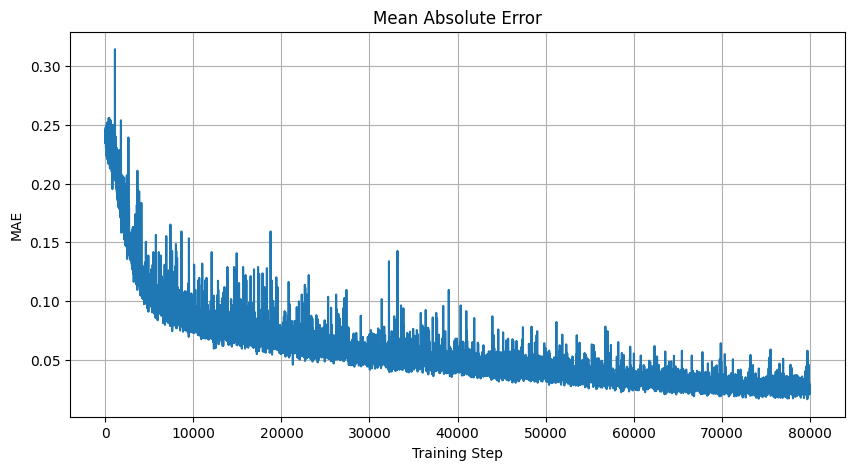

In [5]:
plt.figure()

plt.plot(df["step"], df["mae_loss"])

plt.xlabel("Training Step")
plt.ylabel("MAE")

plt.title("Mean Absolute Error")

plt.grid(True)

plt.show()

#### Plot learning rate

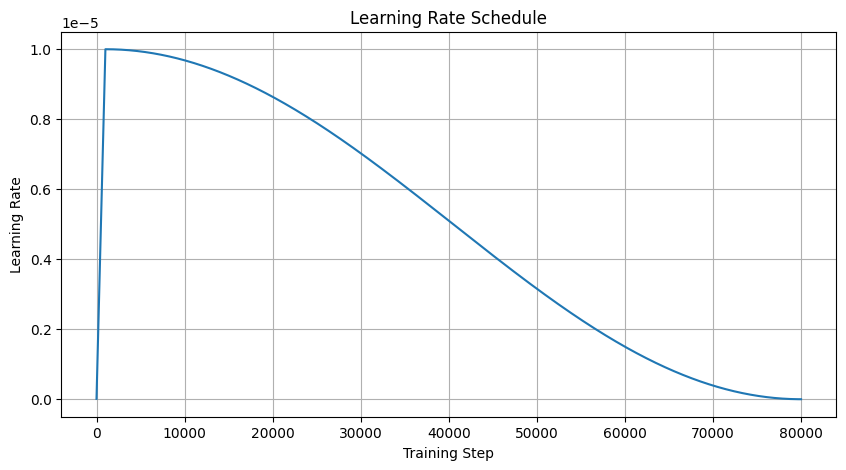

In [6]:
plt.figure()

plt.plot(df["step"], df["learning_rate"])

plt.xlabel("Training Step")
plt.ylabel("Learning Rate")

plt.title("Learning Rate Schedule")

plt.grid(True)

plt.show()

#### Plot gradient norm

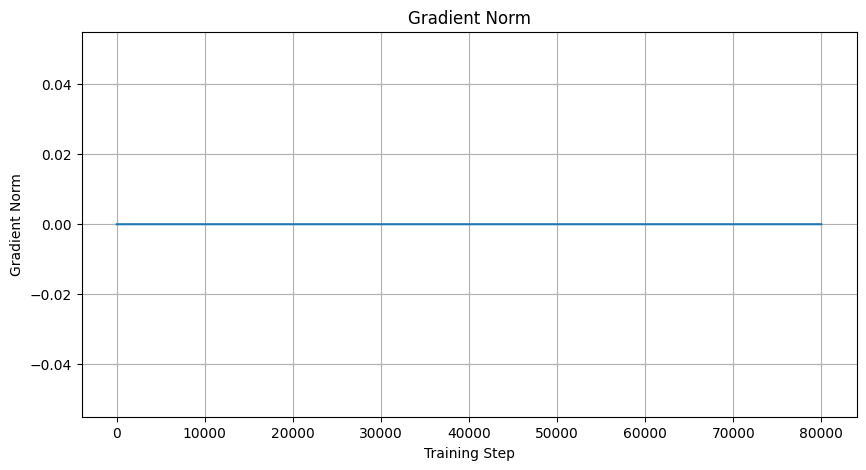

In [7]:
plt.figure()

plt.plot(df["step"], df["grad_norm"])

plt.xlabel("Training Step")
plt.ylabel("Gradient Norm")

plt.title("Gradient Norm")

plt.grid(True)

plt.show()

#### Plot everything together

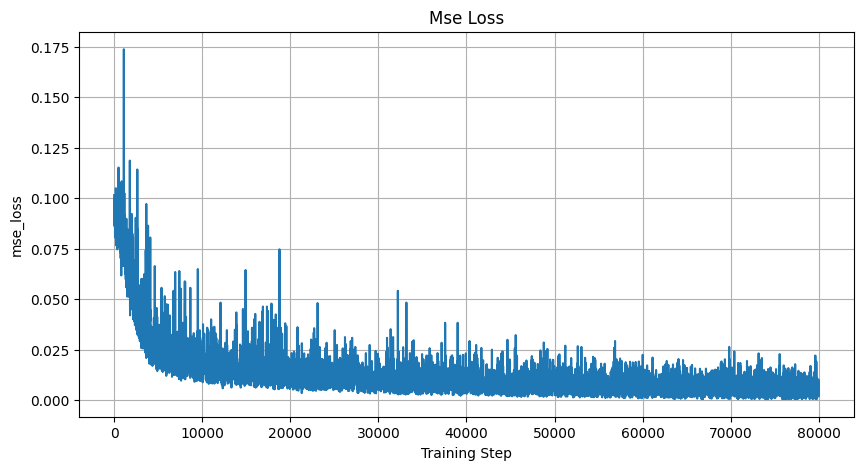

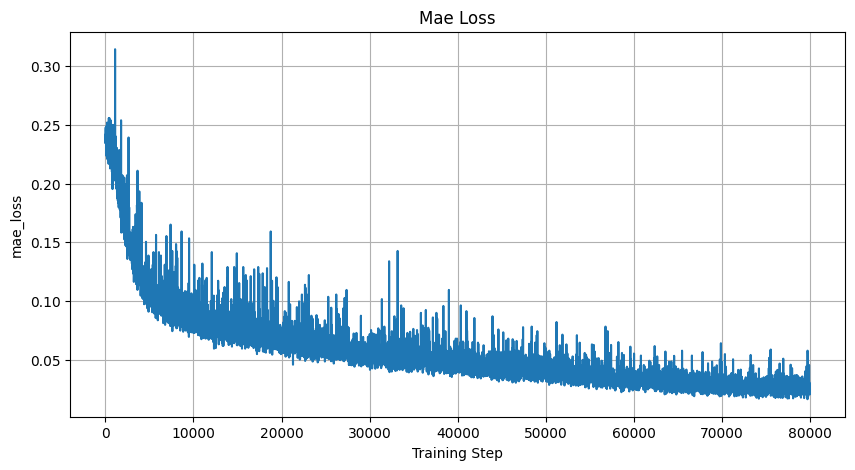

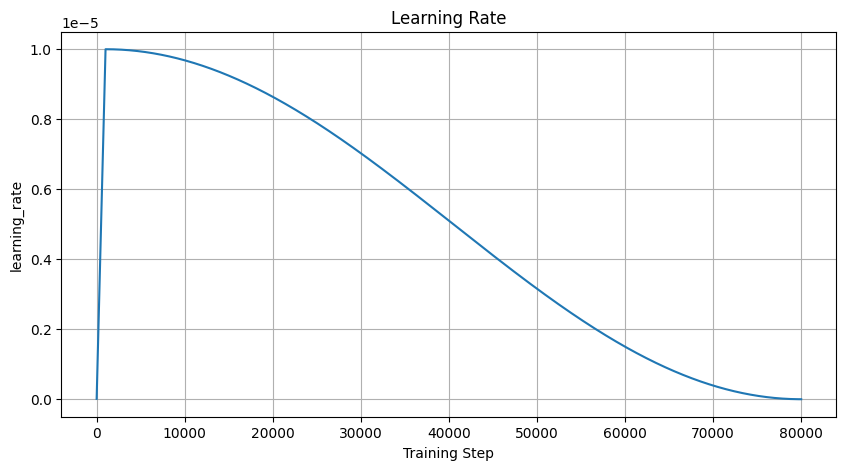

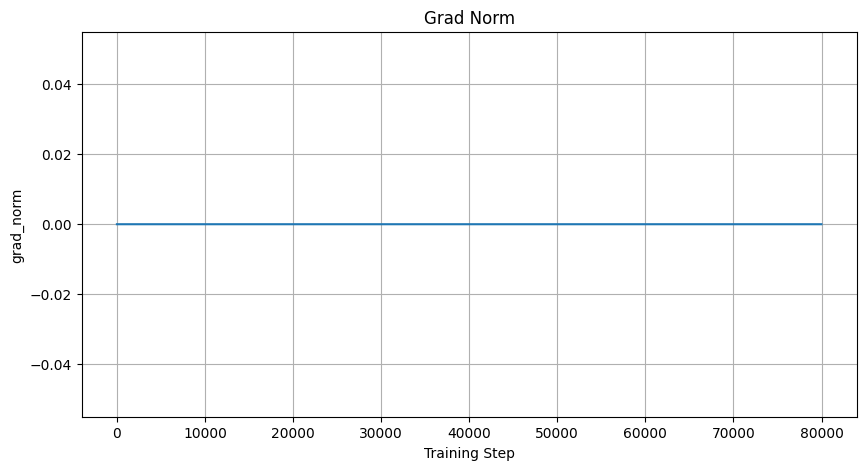

In [8]:
# Define logged metrics
metrics = [
    "mse_loss",
    "mae_loss",
    "learning_rate",
    "grad_norm",
]

# Loop through all metrics, and plot them
for metric in metrics:
    plt.figure()
    plt.plot(df["step"], df[metric])
    plt.xlabel("Training Step")
    plt.ylabel(metric)
    plt.title(metric.replace("_", " ").title())
    plt.grid(True)
    plt.show()

#### Compare multiple training runs

In [ ]:
# Get and sort all training_metrics_*.csv files
files = sorted(LOG_DIR.glob("training_metrics_*.csv"))

# Create figure
plt.figure(figsize=(10,5))

# Loop through all training metrics log files
for f in files:
    run = pd.read_csv(f)
    plt.plot(run["step"], run["mse_loss"], label=f.stem) # Plot MSE loss for each log file/training run

plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.title("Training Run Comparison")
plt.legend(fontsize=7)

plt.grid(True)

plt.show()